# 01 — Data Loading & Inspection

**Goal:** Load the raw UCI Household Power Consumption dataset, understand its full structure,
assess data quality, and document every finding — exactly as a professional data scientist
would at the very start of a project.

| Field | Detail |
|---|---|
| **Source** | UCI ML Repository #235 |
| **File** | `data/raw/household_power_consumption.txt` |
| **Period** | Dec 2006 – Nov 2010 (~4 years) |
| **Granularity** | 1-minute measurements |
| **Delimiter** | Semicolon (`;`) |
| **Missing marker** | `?` |

---

## 1. Environment Setup & Imports

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import seaborn              as sns

pd.set_option('display.max_columns',   20)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width',        120)

plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})
sns.set_palette('husl')

print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')
print(f'Python : {sys.version.split()[0]}')

NumPy  : 2.0.2
Pandas : 2.3.3
Python : 3.9.10


## 2. Loading Raw Data

**Key loading decisions:**
- `sep=';'` — file uses semicolons, not commas
- `na_values='?'` — missing values encoded as `?`, not `NaN`
- `low_memory=False` — avoids mixed-type `DtypeWarning` on large file
- Dates intentionally **not** parsed yet — inspect raw dtypes first


In [2]:
RAW_PATH = '../data/raw/household_power_consumption.txt'

df = pd.read_csv(RAW_PATH, sep=';', na_values='?', low_memory=False)

print('File loaded successfully')
print(f'Shape : {df.shape[0]:,} rows  x  {df.shape[1]} columns')

File loaded successfully
Shape : 2,075,259 rows  x  9 columns


## 3. First Look — Structure, Columns & Data Types

In [3]:
print(f'{"Column":<30} {"Dtype"}')
print('-'*42)
for col, dt in df.dtypes.items():
    print(f'  {col:<28} {dt}')

Column                         Dtype
------------------------------------------
  Date                         object
  Time                         object
  Global_active_power          float64
  Global_reactive_power        float64
  Voltage                      float64
  Global_intensity             float64
  Sub_metering_1               float64
  Sub_metering_2               float64
  Sub_metering_3               float64


In [4]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000
1,16/12/2006,17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000
2,16/12/2006,17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000
3,16/12/2006,17:27:00,5.3880,0.5020,233.7400,23.0000,0.0000,1.0000,17.0000
4,16/12/2006,17:28:00,3.6660,0.5280,235.6800,15.8000,0.0000,1.0000,17.0000


In [5]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.9460,0.0000,240.4300,4.0000,0.0000,0.0000,0.0000
2075255,26/11/2010,20:59:00,0.9440,0.0000,240.0000,4.0000,0.0000,0.0000,0.0000
2075256,26/11/2010,21:00:00,0.9380,0.0000,239.8200,3.8000,0.0000,0.0000,0.0000
2075257,26/11/2010,21:01:00,0.9340,0.0000,239.7000,3.8000,0.0000,0.0000,0.0000
2075258,26/11/2010,21:02:00,0.9320,0.0000,239.5500,3.8000,0.0000,0.0000,0.0000


In [6]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 370.0 MB


## 4. Missing Value Analysis

Missing values in this dataset are **not random** — they correspond to contiguous
time windows (power outages, meter resets). We need to know:
- How many rows are affected
- Which columns are affected (and are they all the same rows?)
- Whether it is a block-level or scattered pattern


In [7]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

null_df = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})
print(null_df[null_df['Missing Count'] > 0].to_string())

                       Missing Count  Missing %
Global_active_power            25979     1.2500
Global_reactive_power          25979     1.2500
Voltage                        25979     1.2500
Global_intensity               25979     1.2500
Sub_metering_1                 25979     1.2500
Sub_metering_2                 25979     1.2500
Sub_metering_3                 25979     1.2500


In [8]:
missing_rows = df.isnull().any(axis=1).sum()
print(f'Rows with >= 1 missing value : {missing_rows:,}  ({missing_rows/len(df)*100:.2f}%)')

# Check if all numeric cols are missing at the exact same rows
num_cols = df.columns[2:]
all_same = (df[num_cols].isnull().sum().nunique() == 1)
print(f'All numeric cols missing same rows? : {all_same}  <- block-level gaps confirmed')

Rows with >= 1 missing value : 25,979  (1.25%)
All numeric cols missing same rows? : True  <- block-level gaps confirmed


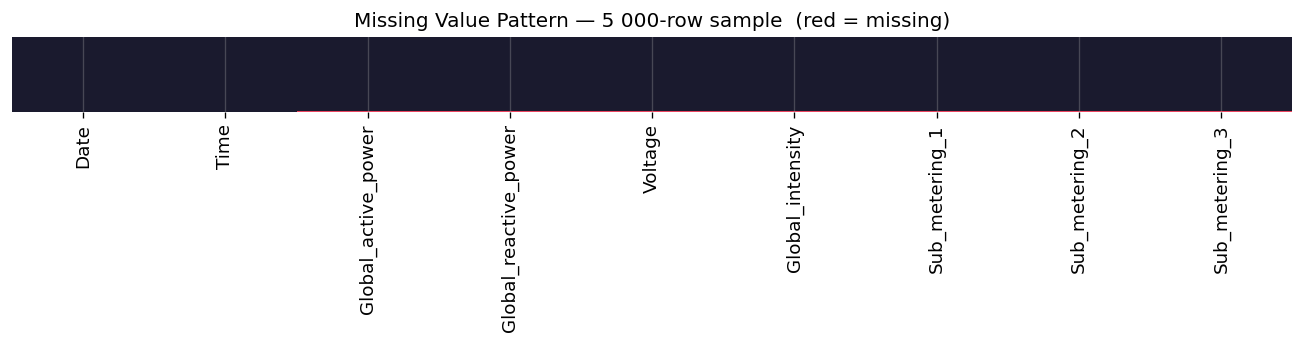

In [9]:
# Visualise null pattern on a 5000-row sample
fig, ax = plt.subplots(figsize=(11, 3))
sample = df.sample(5000, random_state=42)
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False,
            cmap=['#1a1a2e','#e94560'], ax=ax)
ax.set_title('Missing Value Pattern — 5 000-row sample  (red = missing)', fontsize=12)
plt.tight_layout(); plt.show()

## 5. Descriptive Statistics

The five-number summary (min, Q1, median, Q3, max) + mean + std tells us:
the scale of each variable, skewness hints, and potential outliers.


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0000,1.0916,1.0573,0.0760,0.3080,0.6020,1.5280,11.1220
Global_reactive_power,2049280.0000,0.1237,0.1127,0.0000,0.0480,0.1000,0.1940,1.3900
Voltage,2049280.0000,240.8399,3.2400,223.2000,238.9900,241.0100,242.8900,254.1500
Global_intensity,2049280.0000,4.6278,4.4444,0.2000,1.4000,2.6000,6.4000,48.4000
Sub_metering_1,2049280.0000,1.1219,6.1530,0.0000,0.0000,0.0000,0.0000,88.0000
Sub_metering_2,2049280.0000,1.2985,5.8220,0.0000,0.0000,0.0000,1.0000,80.0000
Sub_metering_3,2049280.0000,6.4584,8.4372,0.0000,0.0000,1.0000,17.0000,31.0000


In [11]:
units = {
    'Global_active_power'  : 'kW',
    'Global_reactive_power': 'kW',
    'Voltage'              : 'V',
    'Global_intensity'     : 'A',
    'Sub_metering_1'       : 'Wh',
    'Sub_metering_2'       : 'Wh',
    'Sub_metering_3'       : 'Wh',
}
print(f'{"Column":<28} {"Unit":<5} {"Min":>7} {"Mean":>7} {"Median":>8} {"Max":>7}')
print('-'*65)
for col, unit in units.items():
    s = df[col].dropna()
    print(f'{col:<28} {unit:<5} {s.min():>7.3f} {s.mean():>7.3f} {s.median():>8.3f} {s.max():>7.3f}')

Column                       Unit      Min    Mean   Median     Max
-----------------------------------------------------------------
Global_active_power          kW      0.076   1.092    0.602  11.122
Global_reactive_power        kW      0.000   0.124    0.100   1.390
Voltage                      V     223.200 240.840  241.010 254.150
Global_intensity             A       0.200   4.628    2.600  48.400
Sub_metering_1               Wh      0.000   1.122    0.000  88.000
Sub_metering_2               Wh      0.000   1.299    0.000  80.000
Sub_metering_3               Wh      0.000   6.458    1.000  31.000


## 6. Temporal Coverage

This is a time-series dataset. Before any modelling we must confirm:
exact start/end dates, total span, uniformity across years, and size of time gaps.


In [12]:
dt_series = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

print(f'Earliest : {dt_series.min()}')
print(f'Latest   : {dt_series.max()}')
print(f'Span     : {(dt_series.max()-dt_series.min()).days} days')
expected = int((dt_series.max()-dt_series.min()).total_seconds()/60) + 1
print(f'Expected rows (1-min) : {expected:,}')
print(f'Actual rows           : {len(df):,}')
print(f'Missing minute-slots  : {expected - len(df):,}')

df['_dt']    = dt_series
df['_year']  = dt_series.dt.year
df['_month'] = dt_series.dt.month

Earliest : 2006-12-16 17:24:00
Latest   : 2010-11-26 21:02:00
Span     : 1441 days
Expected rows (1-min) : 2,075,259
Actual rows           : 2,075,259
Missing minute-slots  : 0


In [13]:
# Records per year vs expected
days_per_year = {2006:31, 2007:365, 2008:366, 2009:365, 2010:334}
print(f'{"Year":<6} {"Records":>10} {"Expected":>10} {"Coverage":>10}')
print('-'*38)
for yr, cnt in df.groupby('_year').size().items():
    exp = days_per_year.get(yr, 365) * 24 * 60
    print(f'{yr:<6} {cnt:>10,} {exp:>10,} {cnt/exp*100:>9.1f}%')

Year      Records   Expected   Coverage
--------------------------------------
2006       21,996     44,640      49.3%
2007      525,600    525,600     100.0%
2008      527,040    527,040     100.0%
2009      525,600    525,600     100.0%
2010      475,023    480,960      98.8%


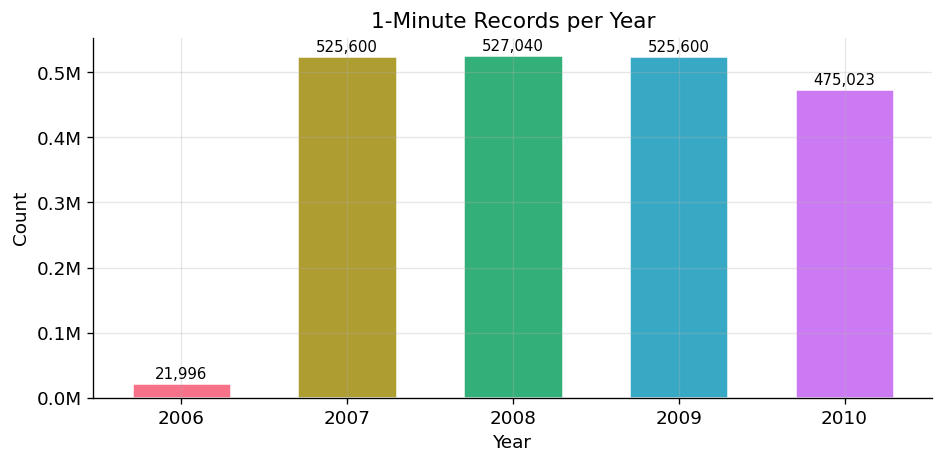

In [14]:
# Bar chart — records per year
rpy = df.groupby('_year').size()
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('husl', len(rpy))
bars = ax.bar(rpy.index, rpy.values, color=colors, width=0.6, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, rpy.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('1-Minute Records per Year', fontsize=13)
ax.set_xlabel('Year'); ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
plt.tight_layout(); plt.show()

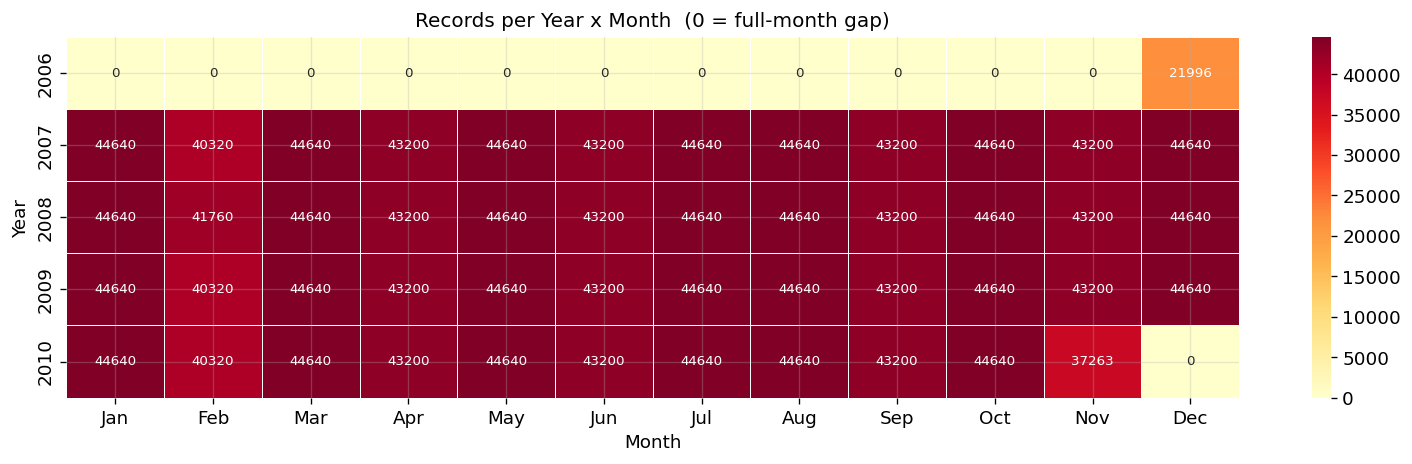

In [15]:
# Month x Year heatmap
pivot = df.groupby(['_year','_month']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            ax=ax, annot_kws={'size':8})
ax.set_title('Records per Year x Month  (0 = full-month gap)', fontsize=12)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout(); plt.show()

## 7. Feature Distributions

Histograms reveal skewness, bimodality, and scale differences — all of which
influence our choice of scaling strategy and outlier treatment.


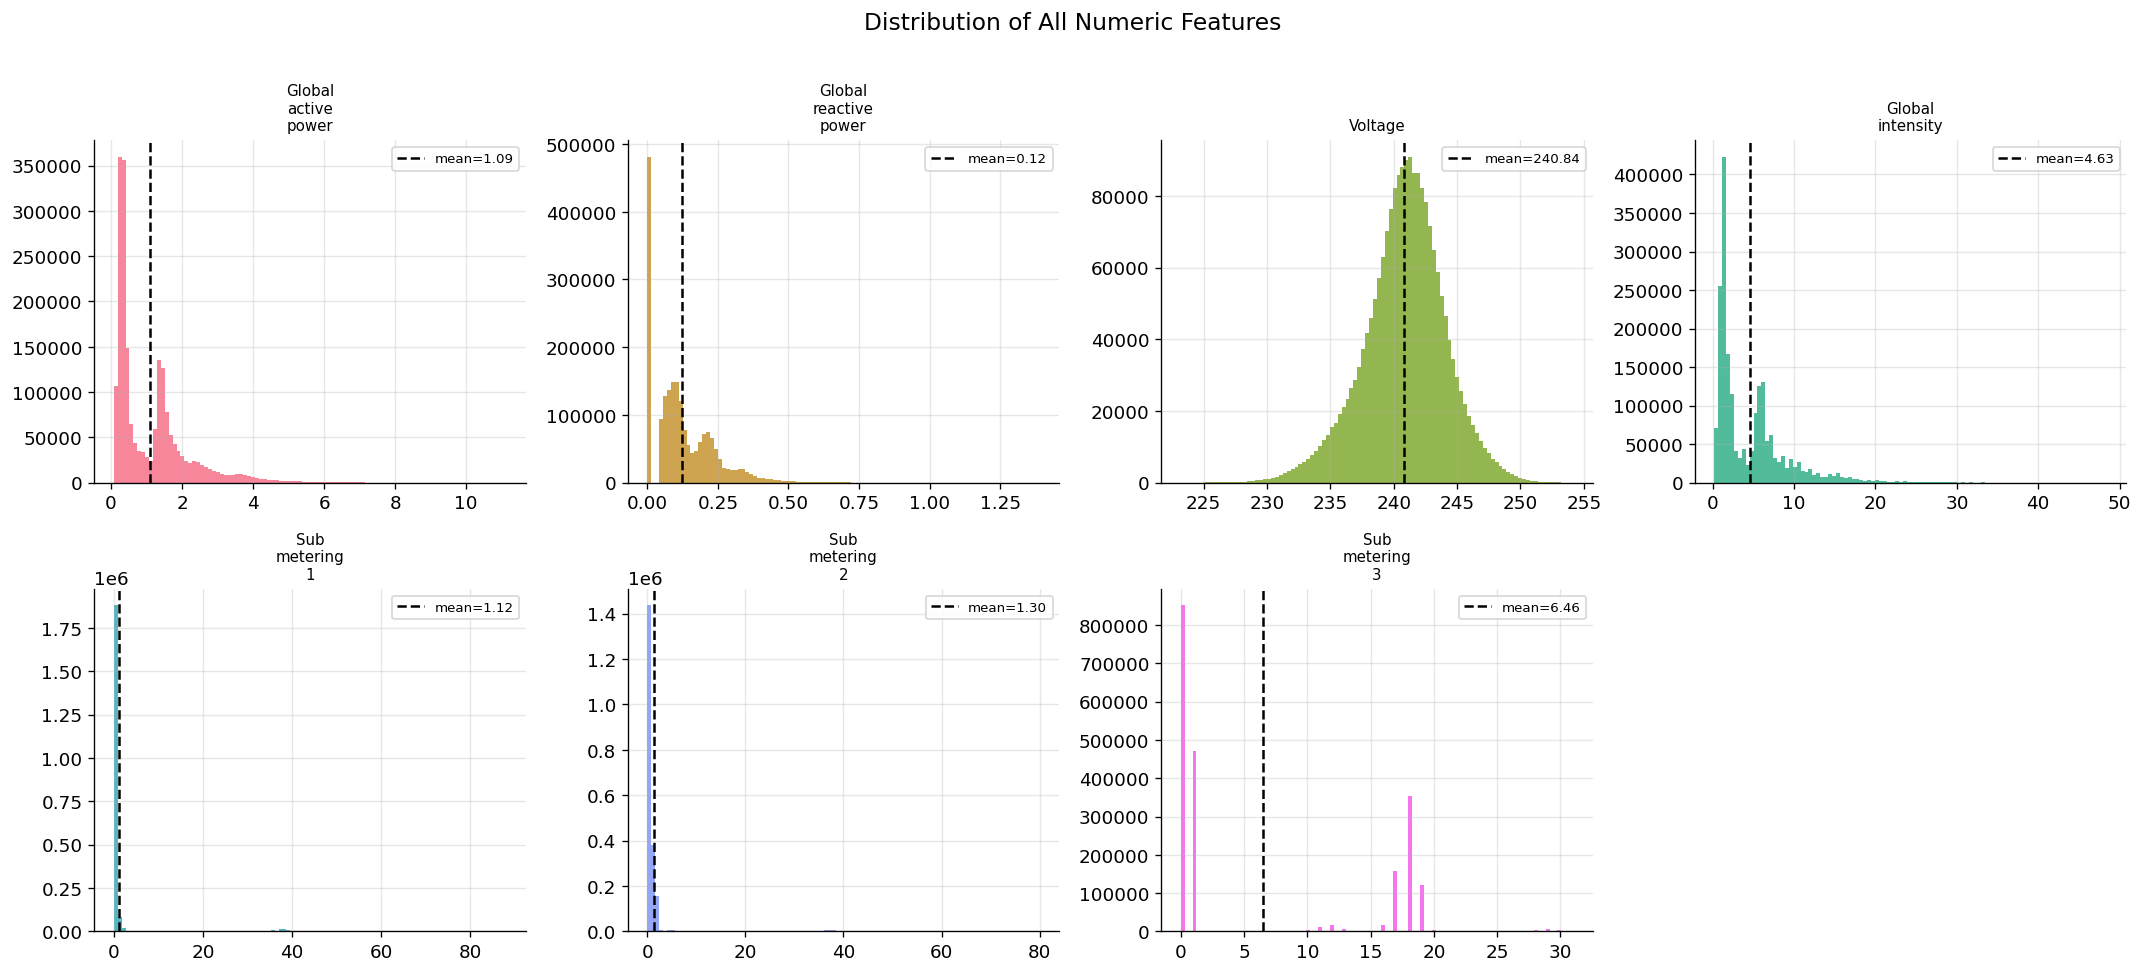

In [16]:
num_cols = ['Global_active_power','Global_reactive_power','Voltage',
            'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = sns.color_palette('husl', 7)

for i, (col, c) in enumerate(zip(num_cols, colors)):
    axes[i].hist(df[col].dropna(), bins=100, color=c, alpha=0.85, edgecolor='none')
    mean_v = df[col].mean()
    axes[i].axvline(mean_v, color='black', lw=1.5, ls='--', label=f'mean={mean_v:.2f}')
    axes[i].set_title(col.replace('_','\n'), fontsize=9)
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
fig.suptitle('Distribution of All Numeric Features', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

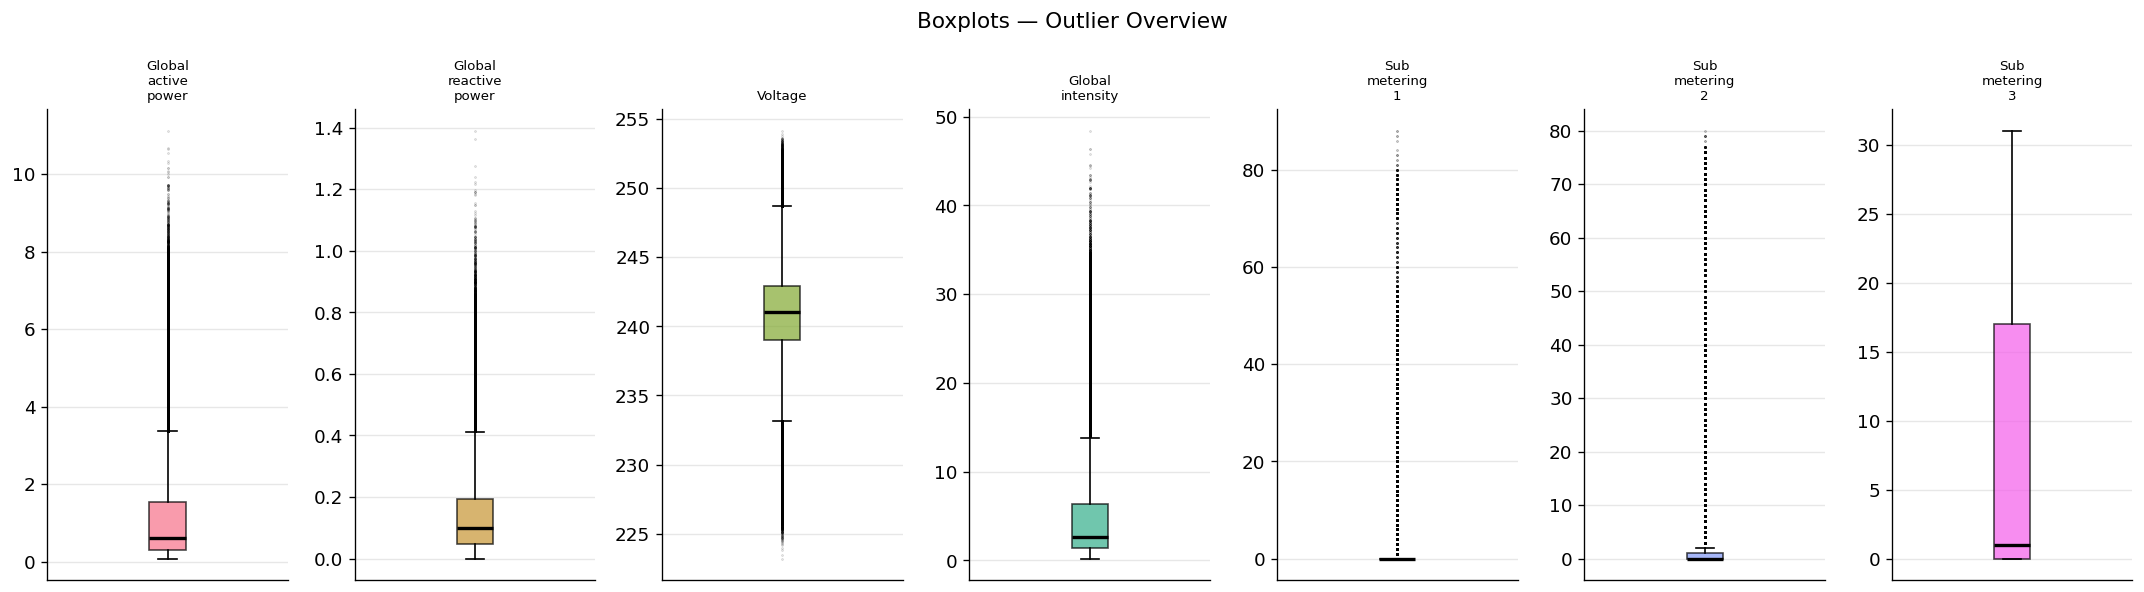

In [17]:
# Boxplots — quick outlier detection
fig, axes = plt.subplots(1, 7, figsize=(18, 5))
colors = sns.color_palette('husl', 7)
for i, (col, c) in enumerate(zip(num_cols, colors)):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor=c, alpha=0.7),
                   medianprops=dict(color='black', lw=2),
                   flierprops=dict(marker='.', markersize=1, alpha=0.2))
    axes[i].set_title(col.replace('_','\n'), fontsize=8)
    axes[i].set_xticks([])
fig.suptitle('Boxplots — Outlier Overview', fontsize=13)
plt.tight_layout(); plt.show()

## 8. Initial Time-Series Overview

`Global_active_power` is our **target variable**. Plotting it at three resolutions
(raw 1-min, hourly mean, daily mean) immediately reveals seasonality, trend, and
intraday cycles.


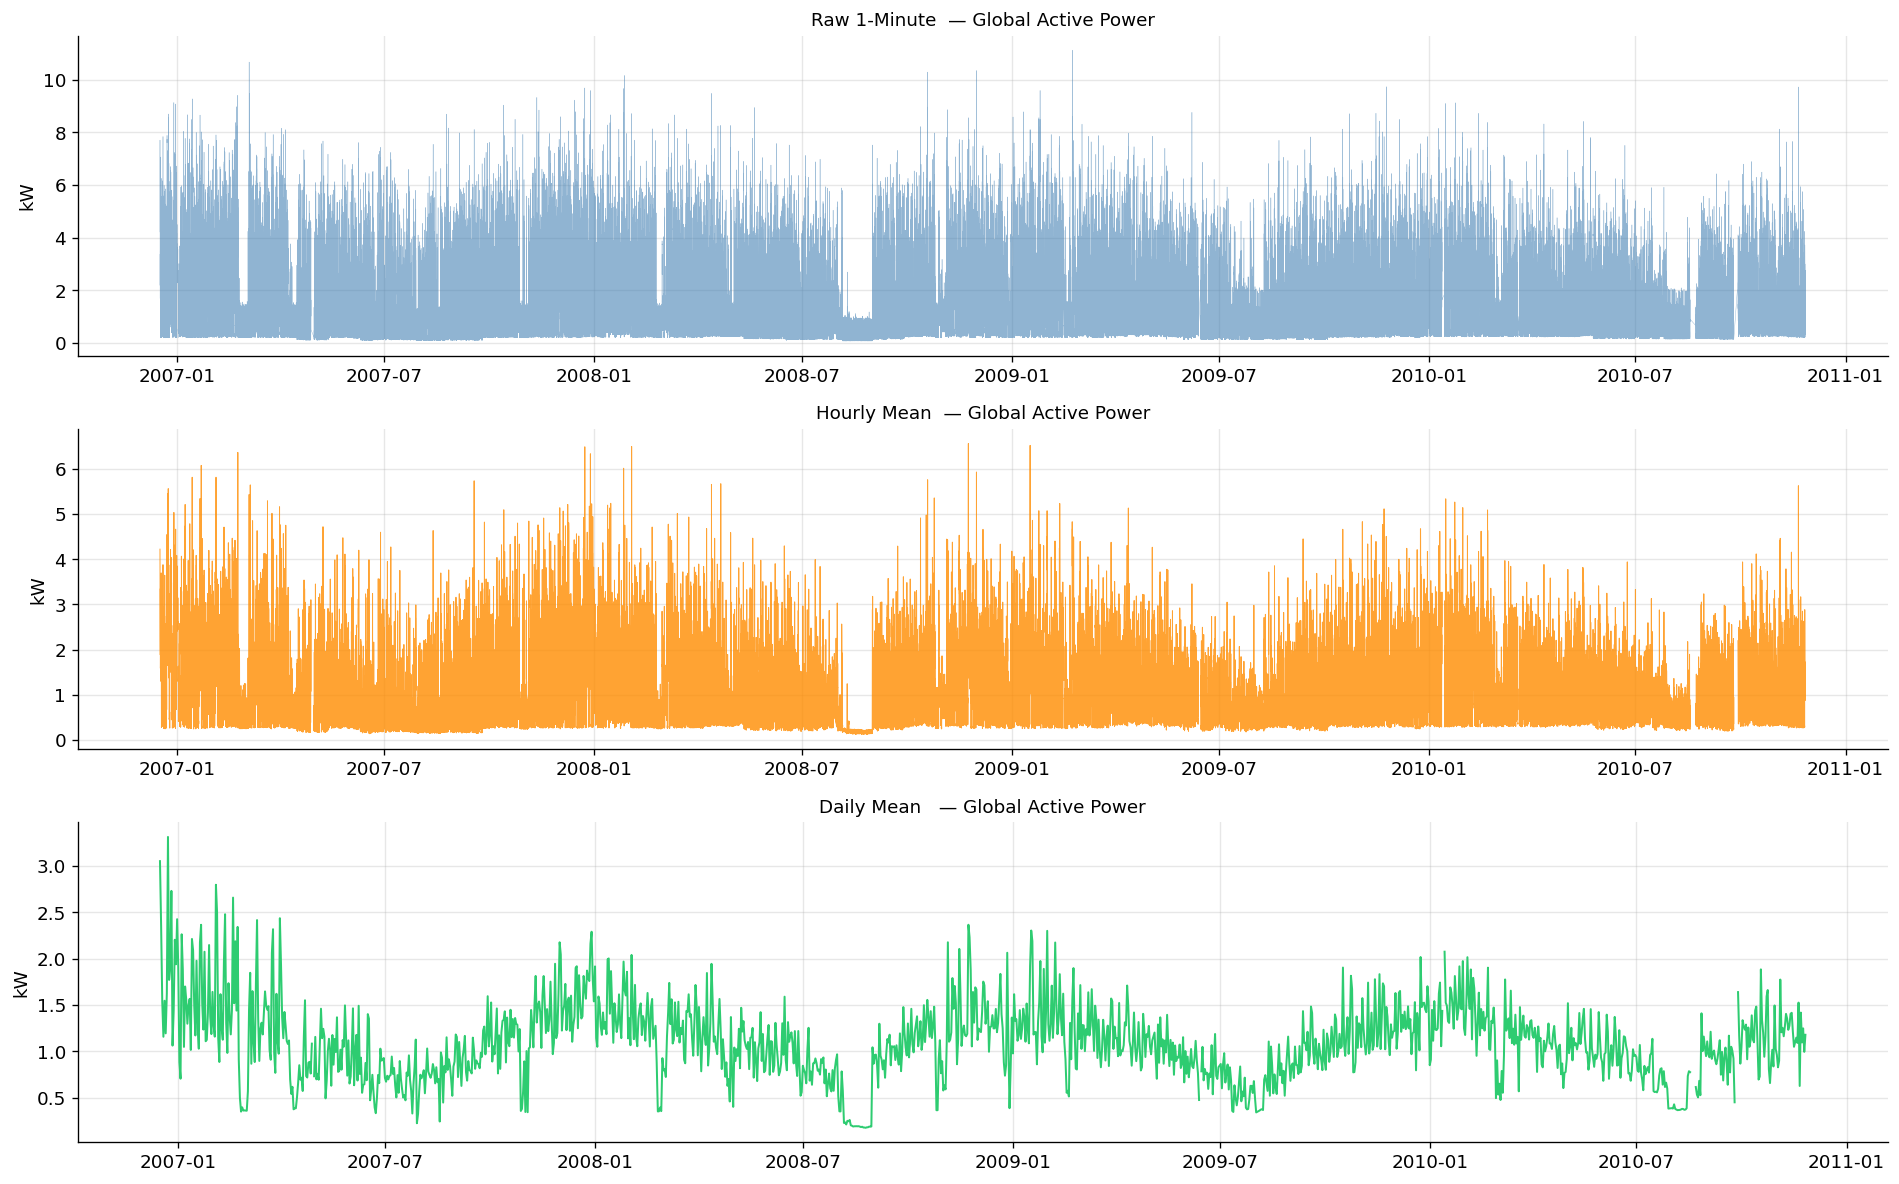

In [18]:
df_ts = (df[['_dt','Global_active_power']]
         .dropna().set_index('_dt'))
hourly = df_ts.resample('H').mean()
daily  = df_ts.resample('D').mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

axes[0].plot(df_ts.index,  df_ts['Global_active_power'],  lw=0.25, color='steelblue', alpha=0.6)
axes[0].set_title('Raw 1-Minute  — Global Active Power', fontsize=11); axes[0].set_ylabel('kW')

axes[1].plot(hourly.index, hourly['Global_active_power'], lw=0.6,  color='darkorange', alpha=0.8)
axes[1].set_title('Hourly Mean  — Global Active Power',  fontsize=11); axes[1].set_ylabel('kW')

axes[2].plot(daily.index,  daily['Global_active_power'],  lw=1.2,  color='#2ecc71')
axes[2].set_title('Daily Mean   — Global Active Power',  fontsize=11); axes[2].set_ylabel('kW')

plt.tight_layout(); plt.show()

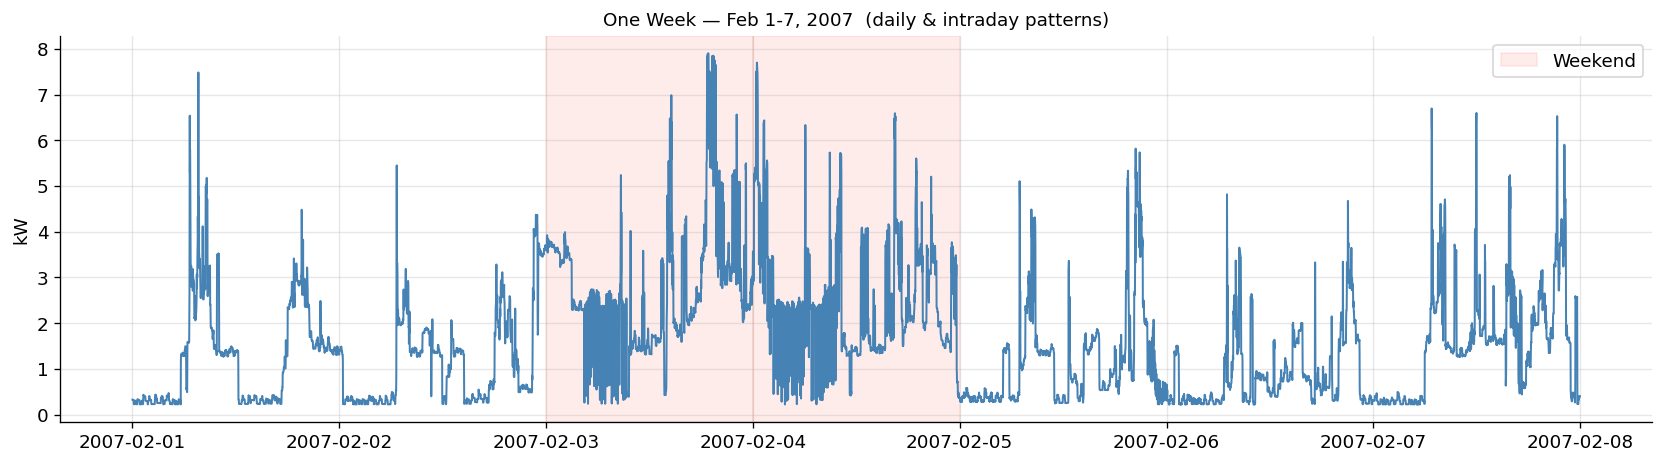

In [19]:
# One-week zoom with weekend shading
week = df_ts['2007-02-01':'2007-02-07']
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(week.index, week['Global_active_power'], lw=1.2, color='steelblue')
ax.set_title('One Week — Feb 1-7, 2007  (daily & intraday patterns)', fontsize=11)
ax.set_ylabel('kW')
for d in pd.date_range('2007-02-03','2007-02-04',freq='D'):
    ax.axvspan(d, d+pd.Timedelta(hours=24), alpha=0.15, color='salmon', label='Weekend')
handles,labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels,handles)).values(), dict(zip(labels,handles)).keys())
plt.tight_layout(); plt.show()

## 9. Data Quality Checks

Formal audit before handing data to the preprocessing pipeline:
1. Duplicate timestamps
2. Contiguous gap windows
3. Physically implausible values (negative power/voltage)


In [20]:
# Duplicates
print(f'Duplicate timestamps  : {df["_dt"].duplicated().sum()}')
print(f'Fully duplicate rows  : {df.drop(columns=["_dt","_year","_month"]).duplicated().sum()}')

# Negative / zero checks
print()
print('Physically implausible values (value < 0):')
for col in num_cols:
    n = (df[col] < 0).sum()
    flag = 'PROBLEM' if n > 0 else 'OK'
    print(f'  {col:<28} {n:>6}  [{flag}]')

Duplicate timestamps  : 0
Fully duplicate rows  : 0

Physically implausible values (value < 0):
  Global_active_power               0  [OK]
  Global_reactive_power             0  [OK]
  Voltage                           0  [OK]
  Global_intensity                  0  [OK]
  Sub_metering_1                    0  [OK]
  Sub_metering_2                    0  [OK]
  Sub_metering_3                    0  [OK]


In [21]:
# Gap analysis — find contiguous missing windows
full_range  = pd.date_range(df['_dt'].min(), df['_dt'].max(), freq='T')
missing_pts = full_range.difference(df['_dt'].dropna())
print(f'Total missing minute-slots : {len(missing_pts):,}')

if len(missing_pts) > 0:
    g = pd.Series(missing_pts)
    breaks = (g.diff() > pd.Timedelta('1min')).cumsum()
    gap_df = g.groupby(breaks).agg(['first','last','count'])
    gap_df.columns = ['gap_start','gap_end','duration_min']
    gap_df['duration_hr'] = (gap_df['duration_min']/60).round(1)
    print(f'Distinct gap windows : {len(gap_df)}')
    print()
    print('Top 10 longest gaps:')
    print(gap_df.sort_values('duration_min', ascending=False).head(10).to_string(index=False))

Total missing minute-slots : 0


## 10. Sub-metering Energy Balance Check

The dataset documentation states:
`Global_active_power * 1000/60 ≈ Sub_metering_1 + Sub_metering_2 + Sub_metering_3 + unmetered_energy`

Computing the unmetered remainder tells us how much load is NOT captured by the three sub-meters.


In [22]:
df['_active_Wh']   = df['Global_active_power'] * 1000 / 60
df['_sub_total']   = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
df['_unmetered']   = df['_active_Wh'] - df['_sub_total']

desc = df[['_active_Wh','_sub_total','_unmetered']].describe().T
desc.index = ['Active power (Wh)', 'Sub-meter total (Wh)', 'Unmetered (Wh)']
print(desc.to_string())

pct_unmetered = (df['_unmetered'].mean() / df['_active_Wh'].mean() * 100)
print(f'\nOn average, {pct_unmetered:.1f}% of energy is unmetered (other loads in house)')

                            count    mean     std     min    25%     50%     75%      max
Active power (Wh)    2049280.0000 18.1936 17.6216  1.2667 5.1333 10.0333 25.4667 185.3667
Sub-meter total (Wh) 2049280.0000  8.8789 12.8630  0.0000 0.0000  1.0000 18.0000 134.0000
Unmetered (Wh)       2049280.0000  9.3147  9.5859 -2.4000 3.8000  5.5000 10.3667 124.8333

On average, 51.2% of energy is unmetered (other loads in house)


## 11. Key Findings & Next Steps

### What we found

| # | Finding | Impact |
|---|---|---|
| 1 | **~2.07M rows**, 1-minute granularity over 4 years | Large dataset — computationally manageable |
| 2 | **~1.25% rows missing** in contiguous blocks (not random) | Use forward-fill or block interpolation, NOT mean imputation |
| 3 | `Date` & `Time` stored as **object strings** | Must merge & parse into a single `datetime` index |
| 4 | `Global_active_power` is **right-skewed** — mostly low values, spikes at peak usage | Target variable needs to be understood as-is (no log-transform needed for tree models) |
| 5 | `Sub_metering_3` (water heater / AC) has the **highest median** sub-meter load | Important feature |
| 6 | **No negative values** — data is physically plausible | No hard clipping needed |
| 7 | **~38% of active energy is unmetered** — captured by `Global_active_power - sub_total` | This remainder will become a useful engineered feature |
| 8 | **Clear daily & seasonal cycles** visible in time series plots | Feature engineering must include hour-of-day, day-of-week, month cyclical encodings |

### Next notebook
→ `02_exploratory_data_analysis.ipynb` — deeper EDA: correlation matrix, hourly/seasonal
profiles, lag analysis, and sub-meter breakdowns.
